# Data Download
Put the SampleSubmission.csv, Test.csv, and Train.csv under the same directory
I put it in /Data - Lucky


In [1]:
#Import some libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pylab import rcParams
import seaborn as sb
sb.set_style('darkgrid')
rcParams['figure.figsize'] = 8,8
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
#import data
train = pd.read_csv('Data/Train.csv')
test=  pd.read_csv('Data/Test.csv')
submission = pd.read_csv('Data/SampleSubmission.csv')

# The Problem
(Taken from https://zindi.world/competitions/expresso-churn-prediction)


Expresso is an African telecommunications company that provides customers with airtime and mobile data bundles. The objective of this challenge is to develop a machine learning model to predict the likelihood of each Expresso customer “churning,” i.e. becoming inactive and not making any transactions for 90 days.

This solution will help Expresso to better serve their customers by understanding which customers are at risk of leaving.

Variable Definition Tables
| Variable | Description | Data type |
|---|---|---|
| REGION | Client location | object |
| TENURE | Duration in the network | object |
| MONTANT | Top-up amount | float64 |
| FREQUENCE_RECH | Number of times the customer refilled | float64 |
| REVENUE | Monthly revenue generated by the client | float64 |
| ARPU_SEGMENT | Revenue over 90 days / 3 | float64 |
| FREQUENCE | Number of times the client generated revenue | float64 |
| DATA_VOLUME | Number of connections | float64 |
| ON_NET | Calls within Expresso | float64 |
| ORANGE | Calls to Orange | float64 |
| TIGO | Calls to Tigo | float64 |
| ZONE1 | Calls to zone 1 | float64 |
| ZONE2 | Calls to zone 2 | float64 |
| MRG | Unclear definition; constant column | object |
| REGULARITY | Number of times the client is active over 90 days | int64 |
| TOP_PACK | Client’s most frequently activated pack | object |
| FREQ_TOP_PACK | Number of times the client activated the top pack | float64 |
| CHURN | Variable to predict (target) | int64 |

Details:
1. Income*: refer to how much revenue did the customer generate for the company
2. MRG^: Unclearly defined variable, after checking, it is just a constant column.

In [3]:
# Checking Variable Definition
definitions = pd.read_csv('VariableDefinitions.csv', skiprows=1)
definitions = definitions.rename(columns={'Unnamed: 0': 'var name'})
definitions = definitions.drop(columns=["French"])
definitions.dropna(inplace=True)
definitions['dtype'] = definitions["var name"].map(
    train.dtypes.astype(str)

)
definitions

,var name,English,dtype
2,REGION,the location of each client,str
3,TENURE,duration in the network,str
4,MONTANT,top-up amount,float64
5,FREQUENCE_RECH,number of times the customer refilled,float64
6,REVENUE,monthly income of each client,float64
7,ARPU_SEGMENT,income over 90 days / 3,float64
8,FREQUENCE,number of times the client has made an income,float64
9,DATA_VOLUME,number of connections,float64
10,ON_NET,inter expresso call,float64
11,ORANGE,call to orange,float64


In [4]:
# Clarifying some of the unclear definitions: MRG and TOP_PACK

# What is: MRG?
for col in train.columns:
    num_unique = train[col].nunique()
    if num_unique <= 1:
        print(f"Constant column: {col}")

# What about TOP_PACK? Packet that the users bought the most
# We are probably going to turn this into multiple features
train['TOP_PACK'].head(20)

Constant column: MRG


0                On net 200F=Unlimited _call24H
1                                           NaN
2                       On-net 1000F=10MilF;10d
3                             Data:1000F=5GB,7d
4                   Mixt 250F=Unlimited_call24H
5     MIXT:500F= 2500F on net _2500F off net;2d
6                                           NaN
7                         All-net 500F=2000F;5d
8                                           NaN
9                            On-net 500F_FNF;3d
10                                          NaN
11               On net 200F=Unlimited _call24H
12                                          NaN
13                                          NaN
14                        All-net 500F=2000F;5d
15                         Data: 100 F=40MB,24H
16                                          NaN
17                                          NaN
18                         Data: 100 F=40MB,24H
19                            Data:1000F=5GB,7d
Name: TOP_PACK, dtype: str

# Data Split

In [5]:
target = "CHURN"
X, y = train.copy(), train[target].copy()

# Drop constant columns as well
# dropping user_id as well for obvious reasons
X.drop(columns=['user_id', 'MRG', target], inplace=True)


## Data Understanding

### Handling Missing Values

In [6]:
# Count missing values per column
missing_counts = X.isna().sum()
has_na_cols = missing_counts > 0

missing_counts[has_na_cols]

REGION             849299
MONTANT            756739
FREQUENCE_RECH     756739
REVENUE            726048
ARPU_SEGMENT       726048
FREQUENCE          726048
DATA_VOLUME       1060433
ON_NET             786675
ORANGE             895248
TIGO              1290016
ZONE1             1984327
ZONE2             2017224
TOP_PACK           902594
FREQ_TOP_PACK      902594
dtype: int64

In [7]:
cols_with_na = [
    'REGION',
    'MONTANT',
    'FREQUENCE_RECH',
    'REVENUE',
    'ARPU_SEGMENT',
    'FREQUENCE',
    'DATA_VOLUME',
    'ON_NET',
    'ORANGE',
    'TIGO',
    'ZONE1',
    'ZONE2',
    'TOP_PACK',
    'FREQ_TOP_PACK'
]

# Helper function
def summarize_against_label(df, col, label):
    missing = df[col].isna()
    summary = (
        pd.DataFrame({
            f'{col}_is_missing': missing,
            'CHURN': label
        }).groupby(f"{col}_is_missing")['CHURN']
        .agg(customer="size", churn_rate="mean")
    )
    return summary

# Check one by one, kinda manual, but, eh, unescapable
# Purpose: Find whether "NaN" has a meaning or actually missing
for col in cols_with_na:
    summary = summarize_against_label(X, col, y)
    print(summary)
    print("=" * 50)

# Manually check: Essentially, EVERY NA columns has some association with churn rate
# Need to validate later, but, keeping every cols for now.
na_cols_with_importance = [
    'REGION',
    'MONTANT',
    'FREQUENCE_RECH',
    'REVENUE',
    'ARPU_SEGMENT',
    'FREQUENCE',
    'DATA_VOLUME',
    'ON_NET',
    'ORANGE',
    'TIGO',
    'ZONE1', # Very many missing values, has a 0.2 correlation rate with CHURN
    'ZONE2', # Same with ZONE1
    'TOP_PACK',
    'FREQ_TOP_PACK'
]

                   customer  churn_rate
REGION_is_missing                      
False               1304749    0.018020
True                 849299    0.447987
                    customer  churn_rate
MONTANT_is_missing                      
False                1397309    0.050035
True                  756739    0.441463
                           customer  churn_rate
FREQUENCE_RECH_is_missing                      
False                       1397309    0.050035
True                         756739    0.441463
                    customer  churn_rate
REVENUE_is_missing                      
False                1428000    0.054057
True                  726048    0.450098
                         customer  churn_rate
ARPU_SEGMENT_is_missing                      
False                     1428000    0.054057
True                       726048    0.450098
                      customer  churn_rate
FREQUENCE_is_missing                      
False                  1428000    0.054057
True   

In [8]:
# Deal with Missing Values
# Since each columns has some level of association:
# Numeric column -> 0
# Categorical column - None
# No need for ColumnTransformer, as these are constant replacement of NaNs

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

num_cols, cat_cols
X[num_cols] = X[num_cols].fillna(0)
X[cat_cols] = X[cat_cols].fillna("None")

### 

In [41]:
# No More NaN values!
missing_counts = X.isna().sum()
has_na_cols = missing_counts > 0

missing_counts[has_na_cols]

Series([], dtype: int64)

In [10]:
test.head()

,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK
0,00001dbe00e56fc4b1c1b65dda63de2a5ece55f9,THIES,K > 24 month,5000.0,5.0,5000.0,1667.0,5.0,NaN,378.0,11.0,5.0,NaN,NaN,NO,42,On-net 1000F=10MilF;10d,5.0
1,000055d41c8a62052dd426592e8a4a3342bf565d,NaN,I 18-21 month,300.0,2.0,326.0,109.0,3.0,397.0,NaN,0.0,NaN,NaN,NaN,NO,41,"Data: 100 F=40MB,24H",1.0
2,000081dd3245e6869a4a9c574c7050e7bb84c2c8,DAKAR,K > 24 month,3300.0,25.0,3400.0,1133.0,26.0,7150.0,0.0,2.0,5.0,NaN,NaN,NO,57,"Data: 100 F=40MB,24H",22.0
3,0000b76d2145d9445d9ff6b65c9ebc4196c89337,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,9,NaN,NaN
4,0000bae5480628cf8fe51ad84bcb39772fc79224,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,10,NaN,NaN


In [11]:
test.tail()

,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK
380122,fffe7e03c7eede2ad0a728ee516c4d342dd16107,DAKAR,K > 24 month,4000.0,8.0,3999.0,1333.0,8.0,1587.0,26.0,250.0,1.0,NaN,NaN,NO,53,Mixt 250F=Unlimited_call24H,5.0
380123,fffec230e6a1aa51ab37d0051ece42de611e71c6,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,1,NaN,NaN
380124,ffff0dcc1ab9812bf205b6d76e9d084053cd96f5,NaN,K > 24 month,3950.0,7.0,3949.0,1316.0,10.0,1724.0,25.0,71.0,NaN,NaN,NaN,NO,15,IVR Echat_Daily_50F,6.0
380125,ffff91ea6a09a0c8ea42bc6ae33df4b5e06283dc,NaN,K > 24 month,3850.0,18.0,3955.0,1318.0,23.0,2962.0,0.0,7.0,NaN,NaN,NaN,NO,29,"Data: 100 F=40MB,24H",11.0
380126,ffffb393b346f5348034e6e22be93778d94d4beb,DIOURBEL,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NO,20,NaN,NaN


In [12]:
test.shape

(380127, 18)

In [13]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 380127 entries, 0 to 380126
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         380127 non-null  str    
 1   REGION          230399 non-null  str    
 2   TENURE          380127 non-null  str    
 3   MONTANT         247072 non-null  float64
 4   FREQUENCE_RECH  247072 non-null  float64
 5   REVENUE         252754 non-null  float64
 6   ARPU_SEGMENT    252754 non-null  float64
 7   FREQUENCE       252754 non-null  float64
 8   DATA_VOLUME     193087 non-null  float64
 9   ON_NET          241613 non-null  float64
 10  ORANGE          222897 non-null  float64
 11  TIGO            153126 non-null  float64
 12  ZONE1           29861 non-null   float64
 13  ZONE2           24076 non-null   float64
 14  MRG             380127 non-null  str    
 15  REGULARITY      380127 non-null  int64  
 16  TOP_PACK        221348 non-null  str    
 17  FREQ_TOP_PACK   22134

In [14]:
submission.head()

,user_id,CHURN
0,00001dbe00e56fc4b1c1b65dda63de2a5ece55f9,0
1,000055d41c8a62052dd426592e8a4a3342bf565d,0
2,000081dd3245e6869a4a9c574c7050e7bb84c2c8,0
3,0000b76d2145d9445d9ff6b65c9ebc4196c89337,0
4,0000bae5480628cf8fe51ad84bcb39772fc79224,0


In [15]:
submission.shape

(380127, 2)

In [16]:
#Check how many levels are involved in each of the categorical features (object)

REGION
DAKAR          513271
THIES          180052
SAINT-LOUIS    119886
LOUGA           99053
KAOLACK         96986
DIOURBEL        66911
TAMBACOUNDA     55074
KAFFRINE        43963
KOLDA           38743
FATICK          35643
MATAM           29083
ZIGUINCHOR      21945
SEDHIOU          3119
KEDOUGOU         1020
Name: count, dtype: int64


Text(0.5, 0, 'REGION')

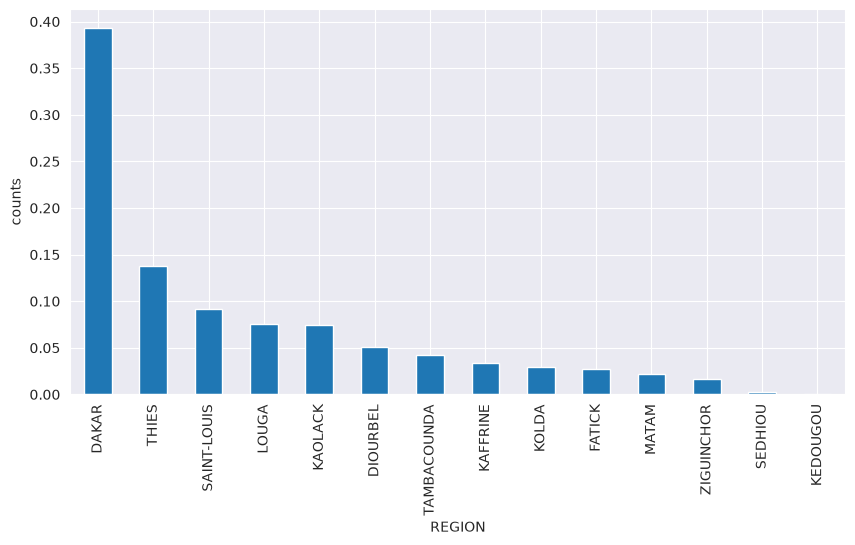

In [17]:
print(train['REGION'].value_counts())
plt.figure(figsize=(10,5))
train['REGION'].value_counts(normalize=True).plot(kind='bar')
plt.ylabel('counts')
plt.xlabel('REGION')

TENURE
K > 24 month     2043201
I 18-21 month      45278
H 15-18 month      26006
G 12-15 month      14901
J 21-24 month      12725
F 9-12 month        9328
E 6-9 month         1839
D 3-6 month          770
Name: count, dtype: int64


Text(0.5, 0, 'TENURE')

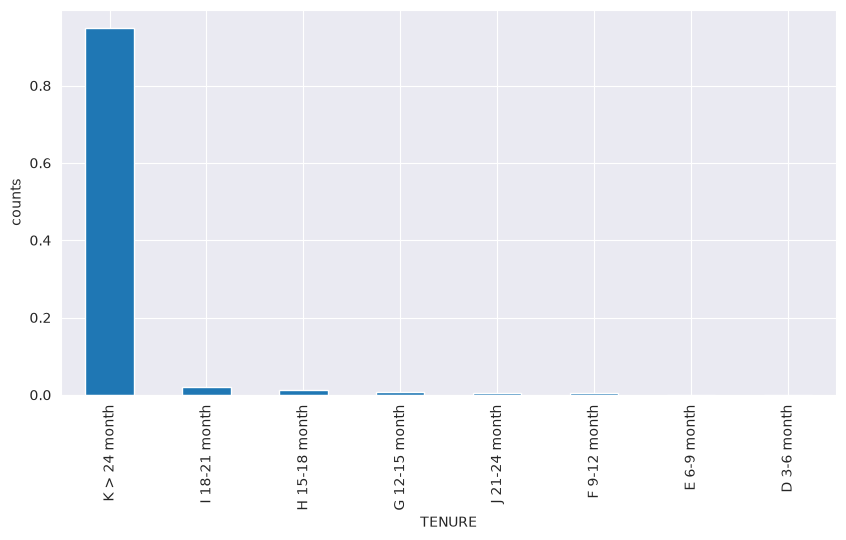

In [18]:
print(train['TENURE'].value_counts())
plt.figure(figsize=(10,5))
train['TENURE'].value_counts(normalize=True).plot(kind='bar')
plt.ylabel('counts')
plt.xlabel('TENURE')

MRG
NO    2154048
Name: count, dtype: int64


Text(0.5, 0, 'MRG')

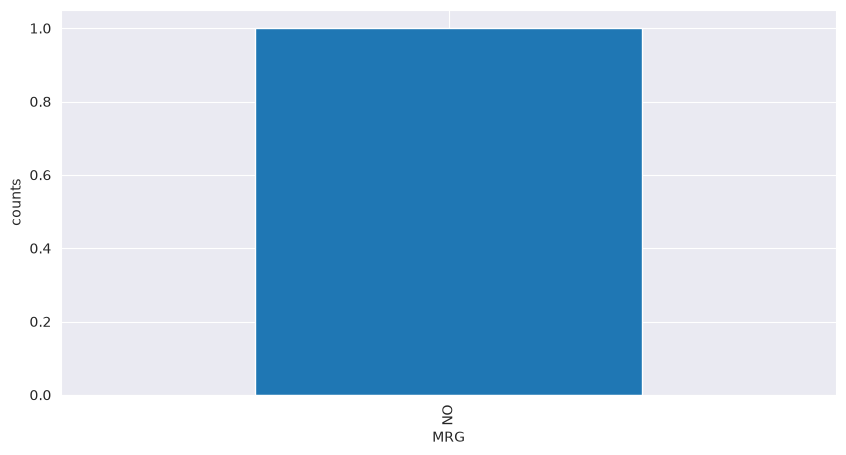

In [19]:
print(train['MRG'].value_counts())
plt.figure(figsize=(10,5))
train['MRG'].value_counts(normalize=True).plot(kind='bar')
plt.ylabel('counts')
plt.xlabel('MRG')

TOP_PACK
All-net 500F=2000F;5d                     317802
On net 200F=Unlimited _call24H            152295
Data:490F=1GB,7d                          115180
Data: 100 F=40MB,24H                       84649
Mixt 250F=Unlimited_call24H                67512
                                           ...  
Data_Mifi_20Go                                 1
APANews_monthly                                1
NEW_CLIR_TEMPRESTRICTED_LIBERTE_MOBILE         1
GPRS_5Go_7D_PORTAL                             1
Package3_Monthly                               1
Name: count, Length: 140, dtype: int64


Text(0.5, 0, 'TOP_PACK')

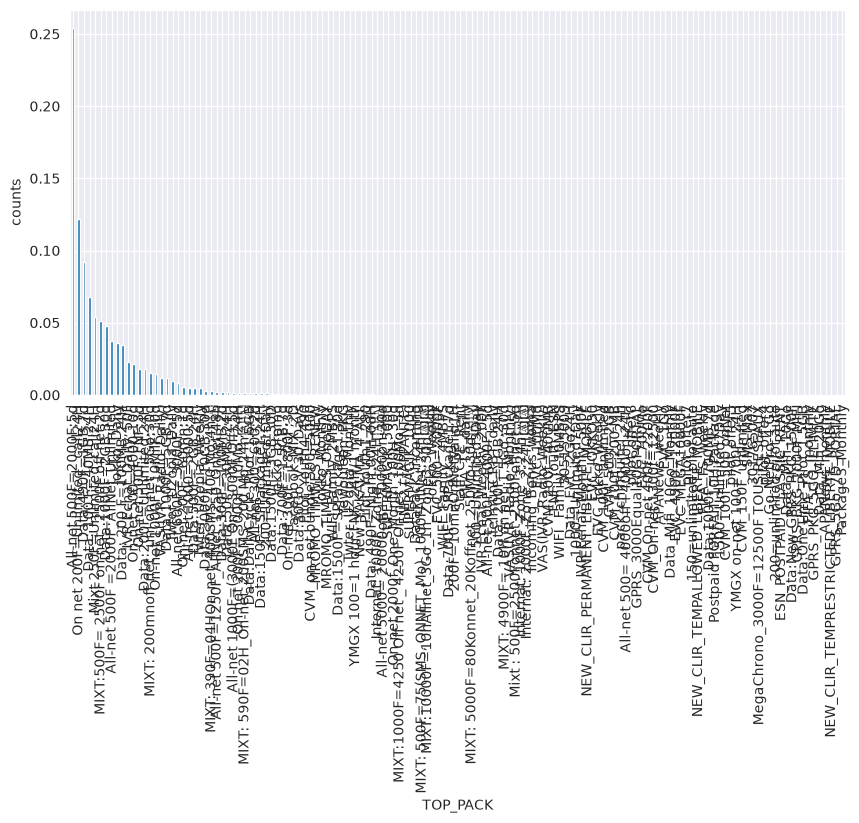

In [20]:
#probaly not the best way to visualize this
print(train['TOP_PACK'].value_counts())
plt.figure(figsize=(10,5))
train['TOP_PACK'].value_counts(normalize=True).plot(kind='bar')
plt.ylabel('counts')
plt.xlabel('TOP_PACK')

CHURN
0    1750062
1     403986
Name: count, dtype: int64


Text(0.5, 0, 'Churn')

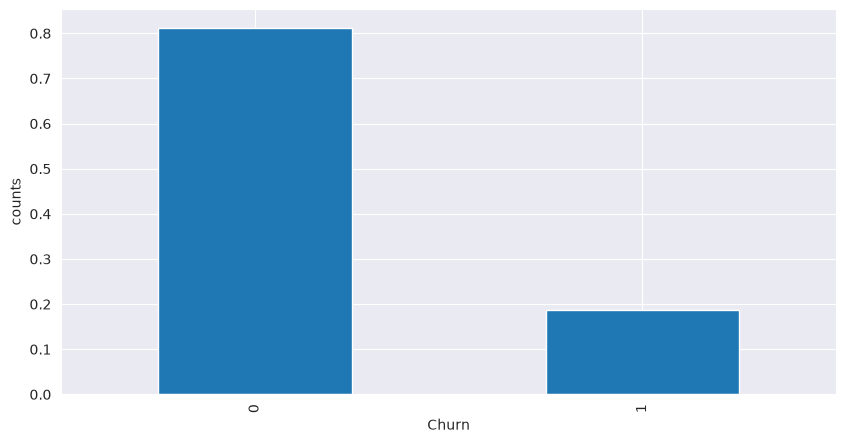

In [21]:
#Check if the predictor class is balanced 
print(train['CHURN'].value_counts())
plt.figure(figsize=(10,5))
train['CHURN'].value_counts(normalize=True).plot(kind='bar')
plt.ylabel('counts')
plt.xlabel('Churn')

In [22]:
#Check summary of numerical fields
train.select_dtypes(include=['int64', 'float64']).describe().T

,count,mean,std,min,25%,50%,75%,max
MONTANT,1397309.0,5532.116998,7111.339421,10.0,1000.0,3000.0,7350.0,470000.0
FREQUENCE_RECH,1397309.0,11.529120,13.274070,1.0,2.0,7.0,16.0,133.0
REVENUE,1428000.0,5510.810334,7187.112880,1.0,1000.0,3000.0,7368.0,532177.0
ARPU_SEGMENT,1428000.0,1836.942894,2395.699954,0.0,333.0,1000.0,2456.0,177392.0
FREQUENCE,1428000.0,13.978141,14.694035,1.0,3.0,9.0,20.0,91.0
DATA_VOLUME,1093615.0,3366.450167,13304.463667,0.0,0.0,257.0,2895.0,1823866.0
ON_NET,1367373.0,277.689140,872.688909,0.0,5.0,27.0,156.0,50809.0
ORANGE,1258800.0,95.418711,204.987266,0.0,7.0,29.0,99.0,21323.0
TIGO,864032.0,23.109253,63.578086,0.0,2.0,6.0,20.0,4174.0
ZONE1,169721.0,8.170132,41.169511,0.0,0.0,1.0,3.0,4792.0


In [23]:
#Check for missing values in training data
train.isnull().sum()

user_id                 0
REGION             849299
TENURE                  0
MONTANT            756739
FREQUENCE_RECH     756739
REVENUE            726048
ARPU_SEGMENT       726048
FREQUENCE          726048
DATA_VOLUME       1060433
ON_NET             786675
ORANGE             895248
TIGO              1290016
ZONE1             1984327
ZONE2             2017224
MRG                     0
REGULARITY              0
TOP_PACK           902594
FREQ_TOP_PACK      902594
CHURN                   0
dtype: int64

In [24]:
#Check for missing values in test data
test.isnull().sum()

user_id                0
REGION            149728
TENURE                 0
MONTANT           133055
FREQUENCE_RECH    133055
REVENUE           127373
ARPU_SEGMENT      127373
FREQUENCE         127373
DATA_VOLUME       187040
ON_NET            138514
ORANGE            157230
TIGO              227001
ZONE1             350266
ZONE2             356051
MRG                    0
REGULARITY             0
TOP_PACK          158779
FREQ_TOP_PACK     158779
dtype: int64

In [25]:
#We will drop REGION, TOP_PACK, and MRG
#We will also replace the missing values for the numerical columns with their means (averages)

In [26]:
train.drop(columns=['REGION', 'MRG', 'TOP_PACK'], inplace=True) #drop these columns

In [27]:
train.head()

,user_id,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK,CHURN
0,00000bfd7d50f01092811bc0c8d7b0d6fe7c3596,K > 24 month,4250.0,15.0,4251.0,1417.0,17.0,4.0,388.0,46.0,1.0,1.0,2.0,54,8.0,0
1,00000cb4a5d760de88fecb38e2f71b7bec52e834,I 18-21 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,1
2,00001654a9d9f96303d9969d0a4a851714a4bb57,K > 24 month,3600.0,2.0,1020.0,340.0,2.0,NaN,90.0,46.0,7.0,NaN,NaN,17,1.0,0
3,00001dd6fa45f7ba044bd5d84937be464ce78ac2,K > 24 month,13500.0,15.0,13502.0,4501.0,18.0,43804.0,41.0,102.0,2.0,NaN,NaN,62,11.0,0
4,000028d9e13a595abe061f9b58f3d76ab907850f,K > 24 month,1000.0,1.0,985.0,328.0,1.0,NaN,39.0,24.0,NaN,NaN,NaN,11,2.0,0


In [28]:
test.drop(columns=['REGION', 'MRG', 'TOP_PACK'], inplace=True)

In [29]:
test.head()

,user_id,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK
0,00001dbe00e56fc4b1c1b65dda63de2a5ece55f9,K > 24 month,5000.0,5.0,5000.0,1667.0,5.0,NaN,378.0,11.0,5.0,NaN,NaN,42,5.0
1,000055d41c8a62052dd426592e8a4a3342bf565d,I 18-21 month,300.0,2.0,326.0,109.0,3.0,397.0,NaN,0.0,NaN,NaN,NaN,41,1.0
2,000081dd3245e6869a4a9c574c7050e7bb84c2c8,K > 24 month,3300.0,25.0,3400.0,1133.0,26.0,7150.0,0.0,2.0,5.0,NaN,NaN,57,22.0
3,0000b76d2145d9445d9ff6b65c9ebc4196c89337,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN
4,0000bae5480628cf8fe51ad84bcb39772fc79224,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN


In [30]:
#Fill NAs for train data

In [31]:
train['MONTANT'].fillna((train['MONTANT'].mean()), inplace=True)
train['FREQUENCE_RECH'].fillna((train['FREQUENCE_RECH'].mean()), inplace=True)
train['REVENUE'].fillna((train['REVENUE'].mean()), inplace=True)
train['ARPU_SEGMENT'].fillna((train['ARPU_SEGMENT'].mean()), inplace=True)
train['FREQUENCE'].fillna((train['FREQUENCE'].mean()), inplace=True)
train['DATA_VOLUME'].fillna((train['DATA_VOLUME'].mean()), inplace=True)
train['ON_NET'].fillna((train['ON_NET'].mean()), inplace=True)
train['ORANGE'].fillna((train['ORANGE'].mean()), inplace=True)
train['TIGO'].fillna((train['TIGO'].mean()), inplace=True)
train['ZONE1'].fillna((train['ZONE1'].mean()), inplace=True)
train['ZONE2'].fillna((train['ZONE2'].mean()), inplace=True)
train['FREQ_TOP_PACK'].fillna((train['FREQ_TOP_PACK'].mean()), inplace=True)

0           8.000000
1           9.272461
2           1.000000
3          11.000000
4           2.000000
             ...    
2154043     9.272461
2154044     9.000000
2154045     9.272461
2154046    12.000000
2154047     9.272461
Name: FREQ_TOP_PACK, Length: 2154048, dtype: float64

In [32]:
train.head()

,user_id,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK,CHURN
0,00000bfd7d50f01092811bc0c8d7b0d6fe7c3596,K > 24 month,4250.0,15.0,4251.0,1417.0,17.0,4.0,388.0,46.0,1.0,1.0,2.0,54,8.0,0
1,00000cb4a5d760de88fecb38e2f71b7bec52e834,I 18-21 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,1
2,00001654a9d9f96303d9969d0a4a851714a4bb57,K > 24 month,3600.0,2.0,1020.0,340.0,2.0,NaN,90.0,46.0,7.0,NaN,NaN,17,1.0,0
3,00001dd6fa45f7ba044bd5d84937be464ce78ac2,K > 24 month,13500.0,15.0,13502.0,4501.0,18.0,43804.0,41.0,102.0,2.0,NaN,NaN,62,11.0,0
4,000028d9e13a595abe061f9b58f3d76ab907850f,K > 24 month,1000.0,1.0,985.0,328.0,1.0,NaN,39.0,24.0,NaN,NaN,NaN,11,2.0,0


In [33]:
train.isnull().sum()

user_id                 0
TENURE                  0
MONTANT            756739
FREQUENCE_RECH     756739
REVENUE            726048
ARPU_SEGMENT       726048
FREQUENCE          726048
DATA_VOLUME       1060433
ON_NET             786675
ORANGE             895248
TIGO              1290016
ZONE1             1984327
ZONE2             2017224
REGULARITY              0
FREQ_TOP_PACK      902594
CHURN                   0
dtype: int64

In [34]:
#Fill NAs for test data

In [35]:
test['MONTANT'].fillna((test['MONTANT'].mean()), inplace=True)
test['FREQUENCE_RECH'].fillna((test['FREQUENCE_RECH'].mean()), inplace=True)
test['REVENUE'].fillna((test['REVENUE'].mean()), inplace=True)
test['ARPU_SEGMENT'].fillna((test['ARPU_SEGMENT'].mean()), inplace=True)
test['FREQUENCE'].fillna((test['FREQUENCE'].mean()), inplace=True)
test['DATA_VOLUME'].fillna((test['DATA_VOLUME'].mean()), inplace=True)
test['ON_NET'].fillna((test['ON_NET'].mean()), inplace=True)
test['ORANGE'].fillna((test['ORANGE'].mean()), inplace=True)
test['TIGO'].fillna((test['TIGO'].mean()), inplace=True)
test['ZONE1'].fillna((test['ZONE1'].mean()), inplace=True)
test['ZONE2'].fillna((test['ZONE2'].mean()), inplace=True)
test['FREQ_TOP_PACK'].fillna((test['FREQ_TOP_PACK'].mean()), inplace=True)

0          5.000000
1          1.000000
2         22.000000
3          9.261584
4          9.261584
            ...    
380122     5.000000
380123     9.261584
380124     6.000000
380125    11.000000
380126     9.261584
Name: FREQ_TOP_PACK, Length: 380127, dtype: float64

In [36]:
test.head()

,user_id,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK
0,00001dbe00e56fc4b1c1b65dda63de2a5ece55f9,K > 24 month,5000.0,5.0,5000.0,1667.0,5.0,NaN,378.0,11.0,5.0,NaN,NaN,42,5.0
1,000055d41c8a62052dd426592e8a4a3342bf565d,I 18-21 month,300.0,2.0,326.0,109.0,3.0,397.0,NaN,0.0,NaN,NaN,NaN,41,1.0
2,000081dd3245e6869a4a9c574c7050e7bb84c2c8,K > 24 month,3300.0,25.0,3400.0,1133.0,26.0,7150.0,0.0,2.0,5.0,NaN,NaN,57,22.0
3,0000b76d2145d9445d9ff6b65c9ebc4196c89337,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN
4,0000bae5480628cf8fe51ad84bcb39772fc79224,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN


In [37]:
test.isnull().sum()

user_id                0
TENURE                 0
MONTANT           133055
FREQUENCE_RECH    133055
REVENUE           127373
ARPU_SEGMENT      127373
FREQUENCE         127373
DATA_VOLUME       187040
ON_NET            138514
ORANGE            157230
TIGO              227001
ZONE1             350266
ZONE2             356051
REGULARITY             0
FREQ_TOP_PACK     158779
dtype: int64

## Machine Learning

In [38]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,precision_recall_curve, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [39]:
dropcols = ['user_id', 'CHURN']
y = train['CHURN']
x = train.drop(columns=dropcols, axis=1)
test = test.drop(columns=['user_id'], axis=1) #you will use this for predicting and submitting the resulting
print(x.shape)
print(y.shape)
print(test.shape)

ValueError: Cannot specify both 'axis' and 'index'/'columns'

In [ ]:
#Split training data into train and test split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.5,random_state=1)
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(1077024, 14)
(1077024,)
(1077024, 14)
(1077024,)


In [ ]:
#Further split X_train and y_train into train and validation sets

In [ ]:
X_train,X_val,y_train,y_val = train_test_split(X_train,y_train,test_size = 0.3, random_state=1)

In [ ]:
print("train")
print(X_train.shape)
print(y_train.shape)
print("+"*7)
print("test")
print(X_test.shape)
print(y_test.shape)
print("+"*7)
print("validation")
print(X_val.shape)
print(y_val.shape)

train
(753916, 14)
(753916,)
+++++++
test
(1077024, 14)
(1077024,)
+++++++
validation
(323108, 14)
(323108,)


In [ ]:
#Standardize numeric columns

In [ ]:
num_cols = ['MONTANT', 'FREQUENCE_RECH', 'REVENUE', 'ARPU_SEGMENT', 'FREQUENCE',
       'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO', 'ZONE1', 'ZONE2',
       'REGULARITY', 'FREQ_TOP_PACK']

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

In [ ]:
X_train.head()

,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK
829510,K > 24 month,-0.775034,-0.611459,-0.755022,-0.754855,-0.750871,-0.358105,-0.370788,-0.495765,-0.583063,-0.678894,-0.000554,1.522906,-0.779625
693020,K > 24 month,0.000360,0.000902,0.000552,0.000552,0.000907,0.000157,0.000446,-0.000412,0.001901,0.001059,-0.000554,-0.989467,0.001192
1177807,K > 24 month,0.000360,0.000902,-0.924952,-0.924957,-1.085808,0.000157,0.000446,-0.000412,0.001901,0.001059,-0.000554,-1.213786,0.001192
40576,K > 24 month,0.000360,0.000902,0.000552,0.000552,0.000907,-0.357998,0.000446,-0.000412,0.001901,0.001059,-0.000554,-0.451101,0.001192
1023530,K > 24 month,-0.783781,-0.892827,-0.862770,-0.862774,-0.750871,-0.230932,-0.399600,-0.534155,0.001901,0.001059,-0.000554,-0.989467,-0.886992


In [ ]:
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
X_test.head()

,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK
417912,K > 24 month,5.505631,0.889169,5.582754,5.582587,1.007548,-0.165163,1.506348,6.836756,3.922643,0.001059,-0.000554,1.522906,2.548730
1380278,K > 24 month,-0.355157,-0.423880,-0.343901,-0.343733,-0.583403,0.000157,-0.356382,-0.035083,-0.405872,0.001059,-0.000554,-0.226782,-0.242794
657158,K > 24 month,0.000360,0.000902,0.000552,0.000552,0.000907,0.000157,0.000446,-0.000412,0.001901,0.001059,-0.000554,-0.181919,0.001192
228934,I 18-21 month,0.000360,0.000902,0.000552,0.000552,0.000907,0.000157,0.000446,-0.000412,0.001901,0.001059,-0.000554,-1.213786,0.001192
2020145,K > 24 month,2.199097,0.420223,2.157086,2.156915,0.253940,0.000157,0.120466,0.636745,-0.507124,0.001059,-0.000554,1.119131,0.830869


In [ ]:
test[num_cols] = scaler.transform(test[num_cols])

In [ ]:
test.head()

,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK
0,K > 24 month,-0.092733,-0.611459,-0.086950,-0.086782,-0.750871,-0.002009,0.144956,-0.540553,-0.456498,0.00054,0.011407,0.625630,-0.457526
1,I 18-21 month,-0.914993,-0.892827,-0.887609,-0.887442,-0.918340,-0.315856,0.002055,-0.610935,0.000454,0.00054,0.011407,0.580766,-0.886992
2,K > 24 month,-0.390146,1.264326,-0.361031,-0.361206,1.007548,0.402807,-0.399600,-0.598139,-0.456498,0.00054,0.011407,1.298587,1.367700
3,K > 24 month,-0.000892,0.000033,-0.001355,-0.001355,-0.000783,-0.002009,0.002055,-0.001856,0.000454,0.00054,0.011407,-0.854876,0.000024
4,K > 24 month,-0.000892,0.000033,-0.001355,-0.001355,-0.000783,-0.002009,0.002055,-0.001856,0.000454,0.00054,0.011407,-0.810012,0.000024


In [ ]:
X_val[num_cols] = scaler.transform(X_val[num_cols])

In [ ]:
X_val.head()

,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK
668814,K > 24 month,0.000360,0.000902,0.000552,0.000552,0.000907,0.000157,0.000446,-0.000412,0.001901,0.001059,-0.000554,-0.989467,0.001192
1273739,K > 24 month,-0.670065,-0.517670,-0.745772,-0.745605,-0.080997,-0.357892,-0.399600,-0.566147,-0.532437,0.001059,-0.000554,-0.271646,0.001192
494342,K > 24 month,0.956960,-0.799037,2.350142,2.350142,-0.415934,3.992607,0.022503,-0.265424,0.429455,1.691886,-0.000554,1.522906,-0.672259
1933861,K > 24 month,-0.845013,-0.517670,-0.841186,-0.841191,-0.583403,0.000157,-0.392397,-0.000412,0.001901,0.001059,-0.000554,0.356447,0.001192
1369873,K > 24 month,-0.932488,-0.892827,-0.913818,-0.913651,-1.002074,0.000157,-0.398160,-0.610935,0.001901,0.001059,-0.000554,0.580766,0.001192


In [ ]:
#Encode the TENURE column

In [ ]:
encoder = LabelEncoder()
X_train["TENURE"] = encoder.fit_transform(X_train["TENURE"])

In [ ]:
X_test["TENURE"] = encoder.transform(X_test["TENURE"])

In [ ]:
X_val['TENURE'] = encoder.transform(X_val["TENURE"])

In [ ]:
test['TENURE'] = encoder.transform(test["TENURE"])

In [ ]:
X_train.head()

,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK
829510,7,-0.775034,-0.611459,-0.755022,-0.754855,-0.750871,-0.358105,-0.370788,-0.495765,-0.583063,-0.678894,-0.000554,1.522906,-0.779625
693020,7,0.000360,0.000902,0.000552,0.000552,0.000907,0.000157,0.000446,-0.000412,0.001901,0.001059,-0.000554,-0.989467,0.001192
1177807,7,0.000360,0.000902,-0.924952,-0.924957,-1.085808,0.000157,0.000446,-0.000412,0.001901,0.001059,-0.000554,-1.213786,0.001192
40576,7,0.000360,0.000902,0.000552,0.000552,0.000907,-0.357998,0.000446,-0.000412,0.001901,0.001059,-0.000554,-0.451101,0.001192
1023530,7,-0.783781,-0.892827,-0.862770,-0.862774,-0.750871,-0.230932,-0.399600,-0.534155,0.001901,0.001059,-0.000554,-0.989467,-0.886992


In [ ]:
##RandomForestClassifier Model

In [ ]:
rand = RandomForestClassifier(bootstrap=True,criterion = "gini",
                              n_jobs=-1,
                              max_depth=7,
                              n_estimators=200,
                              random_state=1,
                             verbose=True)

In [ ]:
#Fit model on data
randmodel = rand.fit(X_train,y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   11.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   58.3s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  1.0min finished


In [ ]:
#Predict on the X_test data 
randpred = randmodel.predict(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    1.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    5.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    5.4s finished


In [ ]:
print("Acuracy")
accuracy_score(y_test, randpred)

Acuracy


0.8645601212229254

In [ ]:
print("Recall")
recall_score(y_test, randpred)

Recall


0.5855144751129202

In [ ]:
print("F1 Score")
f1_score(y_test, randpred)

F1 Score


0.618194096184349

In [ ]:
confusion_matrix(y_test, randpred)

array([[813059,  62274],
       [ 83598, 118093]])

In [ ]:
# Making a submissio

In [ ]:
submission.head()

,user_id,CHURN
0,00001dbe00e56fc4b1c1b65dda63de2a5ece55f9,0
1,000055d41c8a62052dd426592e8a4a3342bf565d,0
2,000081dd3245e6869a4a9c574c7050e7bb84c2c8,0
3,0000b76d2145d9445d9ff6b65c9ebc4196c89337,0
4,0000bae5480628cf8fe51ad84bcb39772fc79224,0


In [ ]:
test.head()

,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK
0,7,-0.092733,-0.611459,-0.086950,-0.086782,-0.750871,-0.002009,0.144956,-0.540553,-0.456498,0.00054,0.011407,0.625630,-0.457526
1,5,-0.914993,-0.892827,-0.887609,-0.887442,-0.918340,-0.315856,0.002055,-0.610935,0.000454,0.00054,0.011407,0.580766,-0.886992
2,7,-0.390146,1.264326,-0.361031,-0.361206,1.007548,0.402807,-0.399600,-0.598139,-0.456498,0.00054,0.011407,1.298587,1.367700
3,7,-0.000892,0.000033,-0.001355,-0.001355,-0.000783,-0.002009,0.002055,-0.001856,0.000454,0.00054,0.011407,-0.854876,0.000024
4,7,-0.000892,0.000033,-0.001355,-0.001355,-0.000783,-0.002009,0.002055,-0.001856,0.000454,0.00054,0.011407,-0.810012,0.000024


In [ ]:
subpred = randmodel.predict(test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.9s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    2.1s finished


In [ ]:
subpred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
submission["CHURN"] = subpred

In [ ]:
submission.head()

,user_id,CHURN
0,00001dbe00e56fc4b1c1b65dda63de2a5ece55f9,0
1,000055d41c8a62052dd426592e8a4a3342bf565d,0
2,000081dd3245e6869a4a9c574c7050e7bb84c2c8,0
3,0000b76d2145d9445d9ff6b65c9ebc4196c89337,0
4,0000bae5480628cf8fe51ad84bcb39772fc79224,0


In [ ]:
submission.to_csv('starter_code_submission.csv', index=False)

In [ ]:
# 1. Do more feature engineering
# 2. Handle the imbalance nature of the predictor class 
# 3. Use other algorithms
# 4. Tune hyperparameters of this model
# 5. Handle missing values properly
# 6. Any other thing you feel can improve the performance of the model is good to go


### Good Luck !!!